<a href="https://colab.research.google.com/github/feyera79-ship-it/Feyera-Gelana/blob/main/Practical_Assignment_for_Module_3_By_Feyera_Gelana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Classification Practical Assignment

## Student Performance Prediction Using Artificial Neural Networks

**Student Name:** Feyera Gelana

### Project Overview

This project develops a deep learning model to predict whether a student will pass or fail based on selected academic and participation-related features. An Artificial Neural Network (ANN) is developed using TensorFlow/Keras.

The complete workflow includes dataset exploration, data preparation, feature scaling, neural network development, model training, regularization, learning-rate control, early stopping, model evaluation, and interpretation of the final results.

# Question 1 – Understanding the Problem and the Data

## 1. Purpose of the Dataset

The purpose of this dataset is to predict whether a student passes or fails based on several academic and participation-related characteristics.The model uses information about study hours, attendance, assignment performance, previous academic performance, and participation to predict the student's final outcome.

The target variable is `passed`, where:

- `1` represents a student who passed.
- `0` represents a student who failed.

This makes the project a binary classification problem.

## 2. Type of Machine Learning Problem

This is a **supervised learning classification problem** because the dataset contains input features and a known target variable (`passed`).

The model learns the relationship between the student characteristics and the known pass/fail outcomes and then uses this relationship to predict the outcome for unseen students.

## 3. Input Features and Target Variable

### Input Features

The independent variables used as inputs to the neural network are:

- `study_hours`
- `attendance`
- `assignment_score`
- `previous_score`
- `participation`

### Target Variable

The dependent variable is:

- `passed`

The target has two possible classes:

- `0` = Failed
- `1` = Passed

## 4. Dataset Size and Quality

The dataset contains **1,000 records and 6 columns**.

There are **5 input features** and **1 target variable**.

The dataset contains no missing values. The missing-value check returned zero missing values for every column.

The class distribution is:

- Passed: **780 students**
- Failed: **220 students**

Therefore, the dataset is not perfectly balanced. There are substantially more students in the passed class than in the failed class.

This class imbalance is important when evaluating the model because accuracy alone may not fully describe how well the model identifies students who fail.

**Step 1: Import Libraries**

 These libraries help us prepare the data, build the neural network, train it, improve it, and evaluate performance.

In [2]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Step 2: Upload and Load Dataset

This allows you to upload student_performance_dataset.csv into Google Colab.

In [3]:
# Load the dataset
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load dataset from CSV file
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/student_performance_dataset.csv")
# Display first 5 rows
data.head()

,study_hours,attendance,assignment_score,previous_score,participation,passed
0,3.745401,51.107976,26.170568,67.270299,5.719959,1
1,9.507143,72.514057,24.697880,79.668140,8.054323,1
2,7.319939,92.376750,90.625458,25.046790,7.601609,1
3,5.986585,83.933493,24.954620,62.487410,1.538999,1
4,1.560186,88.393669,27.194973,57.174598,1.492495,1


Step 3: Inspect the Dataset

Before modeling, we check whether the dataset is complete and whether pass/fail classes are balanced.

In [5]:
# Show dataset size
print("Dataset shape:", data.shape)

# Show column names
print("Columns:", data.columns.tolist())

# Check missing values
print(data.isnull().sum())

# Show target distribution
print(data["passed"].value_counts())

Dataset shape: (1000, 6)
Columns: ['study_hours', 'attendance', 'assignment_score', 'previous_score', 'participation', 'passed']
study_hours         0
attendance          0
assignment_score    0
previous_score      0
participation       0
passed              0
dtype: int64
passed
1    780
0    220
Name: count, dtype: int64


Step 4: Separate Features and Target

# Question 2 – Data Preparation for Deep Learning

## 1. Separating Features and Target

The first preprocessing step is to separate the independent variables from the target variable. The input features are stored in `X`, while the pass/fail outcome is stored in `y`.

This separation is necessary because the neural network should learn patterns from the input features and use the target only as the outcome it is trying to predict.

## 2. Training and Testing Split

The dataset was divided into training and testing sets using an 80/20 split.

The training data is used to teach the neural network, while the testing data is kept separate and used to evaluate how well the trained model performs on unseen data. The `stratify=y` option was used to maintain a similar pass/fail proportion in both the training and testing datasets.

A fixed `random_state=42` was also used so that the split can be reproduced.

## 3. Feature Scaling

StandardScaler was used to standardize the numerical input features.

Feature scaling is particularly important for neural networks because the input variables have different numerical ranges. For example, study hours and participation have much smaller ranges than attendance and previous scores.

Scaling puts the input features on a comparable scale. This helps the neural network optimization process work more efficiently and can make training more stable.

Importantly, the scaler was fitted only on the training data and then used to transform both the training and testing data. This prevents information from the test dataset from influencing the scaling process.

## 4. Preprocessing Summary

The final preprocessing workflow therefore consisted of:

1. Separating input features and target.
2. Splitting the data into training and testing sets.
3. Maintaining the class distribution using stratified splitting.
4. Standardizing the numerical input features.
5. Using the same fitted scaler to transform the test data.

No missing-value treatment was required because the dataset contained no missing values.

In [6]:
# Store all input columns except the target
X = data.drop("passed", axis=1)

# Store the target column
y = data["passed"]

In [7]:
# Count how many students passed and failed
print(data["passed"].value_counts())

passed
1    780
0    220
Name: count, dtype: int64


**Step 5: Split Dataset**

We use 80% of the data for training and 20% for testing. stratify=y keeps the same pass/fail ratio in both sets.

In [8]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Step 6: Scale the Features

Scaling makes all features comparable. This helps neural networks train faster and more reliably.

In [9]:
# Create scaler object
scaler = StandardScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

Step 7: Build the First Artificial Neural Network

# Question 3 – Building and Training the Model with Keras

## 1. Neural Network Architecture

A feed-forward Artificial Neural Network was selected because the dataset contains structured numerical/tabular data and the task is binary classification.

The baseline model uses the following architecture:

**Input Layer → Dense(16, ReLU) → Dense(8, ReLU) → Dense(1, Sigmoid)**

The input layer receives the five scaled input features.

The first hidden layer contains 16 neurons and uses the ReLU activation function.

The second hidden layer contains 8 neurons and also uses ReLU activation.

The final output layer contains one neuron with a sigmoid activation function.

The sigmoid output is appropriate for binary classification because it produces a value between 0 and 1 that can be interpreted as the probability of belonging to the positive class, which in this project is the "passed" class.

The baseline network contains **241 trainable parameters**.

## 2. Why This Architecture Was Selected

The network is relatively small because the dataset contains only five input features and 1,000 observations.

Using two hidden layers allows the network to learn nonlinear relationships between the student characteristics and the pass/fail outcome without creating an unnecessarily complex model. ReLU was selected for the hidden layers because it is commonly used in neural networks and allows the model to learn nonlinear relationships efficiently. Sigmoid was selected for the output layer because the target contains two classes: passed and failed.

## 3. Model Compilation

The model was compiled using:

- Adam optimizer
- Binary cross-entropy loss
- Accuracy as an evaluation metric

Binary cross-entropy is appropriate because this is a binary classification problem. The Adam optimizer adjusts the model weights during training to minimize the loss function.

## 4. Model Training

The baseline model was trained for 50 epochs with a batch size of 32. A validation split of 20% of the training data was used to monitor how well the model generalized during training.

The training results show that the model learned quickly during the early epochs. Training accuracy increased from approximately 73% at the beginning to approximately 90% near the end of training. Validation accuracy reached approximately 88.75% and remained relatively stable during the later epochs.

The validation loss reached its lowest level at approximately 0.308 around Epoch 32 and then remained relatively stable.

This suggests that the baseline model learned useful patterns from the data, although continued training did not produce major improvements in validation performance.

In [10]:
from tensorflow.keras import layers
# Create a basic neural network model
basic_model = keras.Sequential([

    # Input layer based on number of features
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),

    # First hidden layer
    keras.layers.Dense(16, activation="relu"),

    # Second hidden layer
    keras.layers.Dense(8, activation="relu"),

    # Output layer for binary classification
    keras.layers.Dense(1, activation="sigmoid")
])

Step 8: View Neural Network Architecture

In [11]:
# Show model architecture
basic_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

Step 9: Compile the Neural Network

adam updates the model weights.
binary_crossentropy is appropriate for pass/fail prediction.
accuracy measures correct predictions.

In [12]:
# Compile the basic model
basic_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Step 10: Train the Neural Network

We train for 50 epochs to observe whether the model continues improving or begins overfitting.

In [13]:
# Train the basic model
basic_history = basic_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7437 - loss: 0.6313 - val_accuracy: 0.7312 - val_loss: 0.6122
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7797 - loss: 0.5891 - val_accuracy: 0.7688 - val_loss: 0.5804
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7844 - loss: 0.5545 - val_accuracy: 0.7688 - val_loss: 0.5516
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7844 - loss: 0.5236 - val_accuracy: 0.7688 - val_loss: 0.5246
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7844 - loss: 0.4961 - val_accuracy: 0.7750 - val_loss: 0.4993
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7922 - loss: 0.4701 - val_accuracy: 0.7750 - val_loss: 0.4743
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7984 - loss: 0.4438 - val_accuracy: 0.7937 - val_loss: 0.4503
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8188 - loss: 0.4199 - val_accuracy: 0.8125 - val_loss:



Step 11: Visualize Training Performance

If training accuracy increases but validation accuracy stops improving, the model may be overfitting.

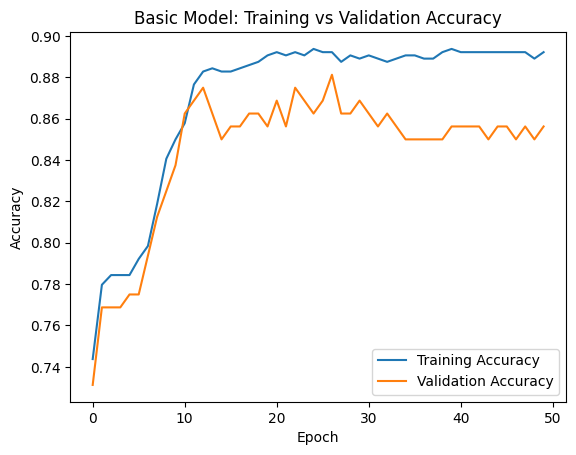

In [14]:
# Plot training accuracy
plt.plot(basic_history.history["accuracy"], label="Training Accuracy")

# Plot validation accuracy
plt.plot(basic_history.history["val_accuracy"], label="Validation Accuracy")

# Add title
plt.title("Basic Model: Training vs Validation Accuracy")

# Add x-axis label
plt.xlabel("Epoch")

# Add y-axis label
plt.ylabel("Accuracy")

# Add legend
plt.legend()

# Show plot
plt.show()

Step 12: Visualize Loss Curves

Loss shows error. If validation loss increases while training loss decreases, the model is overfitting.

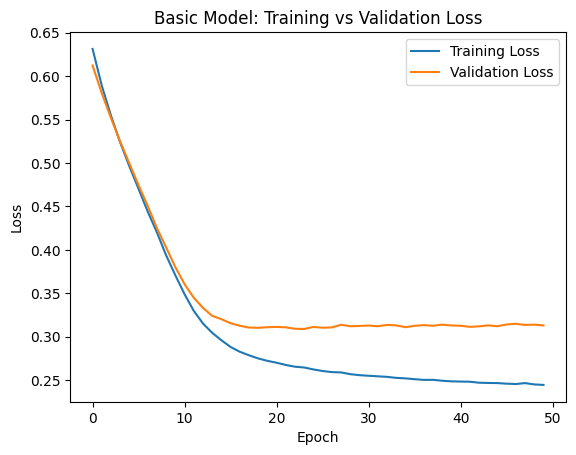

In [15]:
# Plot training loss
plt.plot(basic_history.history["loss"], label="Training Loss")

# Plot validation loss
plt.plot(basic_history.history["val_loss"], label="Validation Loss")

# Add title
plt.title("Basic Model: Training vs Validation Loss")

# Add x-axis label
plt.xlabel("Epoch")

# Add y-axis label
plt.ylabel("Loss")

# Add legend
plt.legend()

# Show plot
plt.show()

Step 13: Understanding Overfitting

Build an Improved Neural Network
Step 14: Build an Improved Model with Dropout

Dropout helps reduce overfitting by preventing the network from depending too much on specific neurons.

In [16]:
# Create improved neural network model
improved_model = keras.Sequential([

    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),

    # First hidden layer with more neurons
    layers.Dense(32, activation="relu"),

    # Dropout layer randomly turns off 30% of neurons during training
    layers.Dropout(0.3),

    # Second hidden layer
    layers.Dense(16, activation="relu"),

    # Dropout layer randomly turns off 20% of neurons during training
    layers.Dropout(0.2),

    # Output layer
    layers.Dense(1, activation="sigmoid")
])

Step 15: Understanding Dropout

In [17]:
print("Dropout Layer 1: 30% neurons disabled during training")

print("Dropout Layer 2: 20% neurons disabled during training")

print("Dropout helps reduce overfitting")

Dropout Layer 1: 30% neurons disabled during training
Dropout Layer 2: 20% neurons disabled during training
Dropout helps reduce overfitting


Step 16: Compile Improved Model with Controlled Learning Rate

The learning rate controls how large the model’s weight updates are. If it is too high, training may become unstable. If it is too low, training may be slow.

In [18]:
# Create Adam optimizer with specific learning rate
optimizer = keras.optimizers.Adam(learning_rate=0.001)

# Compile improved model
improved_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Step 17: Early Stopping

EarlyStopping prevents unnecessary training.
ReduceLROnPlateau lowers learning rate when progress slows.
ModelCheckpoint saves the best version of the model.

In [19]:
# Stop training when validation loss stops improving
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


Step 18: Learning Rate Reduction

Another powerful optimization technique is Learning Rate Reduction.

In [20]:
# Reduce learning rate when validation loss stops improving
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001
)


Step 19: Model Checkpointing

In [21]:
# Save the best model during training
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="best_student_model.keras",
    monitor="val_loss",
    save_best_only=True
)

Step 20: Train the Improved Model

We set a high number of epochs, but early stopping will stop training automatically when the model stops improving.

In [22]:
# Train improved model with callbacks
improved_history = improved_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4563 - loss: 0.7677 - val_accuracy: 0.6187 - val_loss: 0.6640 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6484 - loss: 0.6433 - val_accuracy: 0.7688 - val_loss: 0.5814 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7594 - loss: 0.5674 - val_accuracy: 0.7750 - val_loss: 0.5191 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7844 - loss: 0.5182 - val_accuracy: 0.7937 - val_loss: 0.4710 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8188 - loss: 0.4658 - val_accuracy: 0.8188 - val_loss: 0.4305 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8125 - loss: 0.4356 - val_accuracy: 0.8250 - val_loss: 0.3976 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8344 - loss: 0.3916 - val_ac

Step 21: Evaluate the Improved Model

# Question 5 – Model Evaluation and Interpretation

## 1. Evaluation Metrics

The final model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. These metrics provide a more complete assessment than accuracy alone.

### Accuracy

The final model achieved approximately **83% test accuracy** in the classification report. This means that approximately 83% of the students in the test set were classified correctly.

### Precision

For class 0 (failed), the precision was **0.63**.

For class 1 (passed), the precision was **0.89**.

This means that the model was more precise when predicting students who passed than when predicting students who failed.

### Recall

For class 0 (failed), recall was **0.59**.

For class 1 (passed), recall was **0.90**.

The model therefore identified passed students much more successfully than failed students.

### F1-Score

The F1-score for class 0 was **0.61**, while the F1-score for class 1 was **0.90**.

The lower F1-score for class 0 shows that identifying students who failed remains more difficult for the model.

## 2. Confusion Matrix Interpretation

The confusion matrix was:

[[26, 18],
 [15, 141]]

The matrix can be interpreted as follows:

- 26 failed students were correctly predicted as failed.
- 18 failed students were incorrectly predicted as passed.
- 15 passed students were incorrectly predicted as failed.
- 141 passed students were correctly predicted as passed.

The model therefore performs much better at identifying students who passed than students who failed.

The most important error from an educational-support perspective is that **18 students who actually failed were predicted as passed**. These are false-negative predictions for the failed class because the model failed to identify students who may need additional academic support.

## 3. Which Mistakes Occur Most Often?

The model's most notable classification problem is identifying the failed class.

There were 18 failed students incorrectly classified as passed, compared with 15 passed students incorrectly classified as failed. The relatively low recall of 0.59 for class 0 confirms that the model misses a significant proportion of students who failed.

## 4. Which Evaluation Metric Is Most Important?

For this project, recall for the failed class is particularly important. If the purpose of the model is to identify students who may be at risk of failing, it is important to identify as many of those students as possible.

A model with high overall accuracy could still fail to identify many students who need support, especially when the classes are imbalanced. Therefore, accuracy should be considered together with precision, recall, F1-score, and the confusion matrix.

## 5. Why Can Accuracy Be Misleading?

Accuracy can sometimes be misleading when the classes are imbalanced. In this dataset, 780 students passed while only 220 students failed.

Because the passed class is much larger, a model can obtain relatively high accuracy by performing well on the majority class while performing less effectively on the minority class. For this reason, precision, recall, F1-score, and the confusion matrix provide additional information about how the model performs for each class.

## 6. Would I Trust This Model in a Real Educational Setting?

I would not use this model as the only decision-making system in a real educational setting.

The model has reasonably strong overall performance, but its recall for the failed class is only 59%. This means that some students who actually fail may not be identified by the model. However, the model could be useful as a **supporting early-warning tool**. It could help teachers or academic staff identify students who may need additional attention.

Human judgment and other academic information should still be considered before making important decisions about individual students.

In [23]:
# Evaluate basic model on test data
basic_loss, basic_accuracy = basic_model.evaluate(X_test_scaled, y_test)

# Print basic model results
print("Basic Model Loss:", basic_loss)
print("Basic Model Accuracy:", basic_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8500 - loss: 0.3329  
Basic Model Loss: 0.33293959498405457
Basic Model Accuracy: 0.8500000238418579


In [24]:
# Evaluate improved model on test data
improved_loss, improved_accuracy = improved_model.evaluate(X_test_scaled, y_test)

# Print improved model results
print("Improved Model Loss:", improved_loss)
print("Improved Model Accuracy:", improved_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8500 - loss: 0.3117  
Improved Model Loss: 0.3116951286792755
Improved Model Accuracy: 0.8500000238418579


Step 22: Compare Baseline and Improved Models

This gives students a clear visual comparison between the basic and improved models. This makes the improvement visible and easy for students to understand.

In [25]:
# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Basic Model", "Improved Model"],
    "Test Loss": [basic_loss, improved_loss],
    "Test Accuracy": [basic_accuracy, improved_accuracy]
})

# Show comparison
print(comparison)

            Model  Test Loss  Test Accuracy
0     Basic Model   0.332940           0.85
1  Improved Model   0.311695           0.85


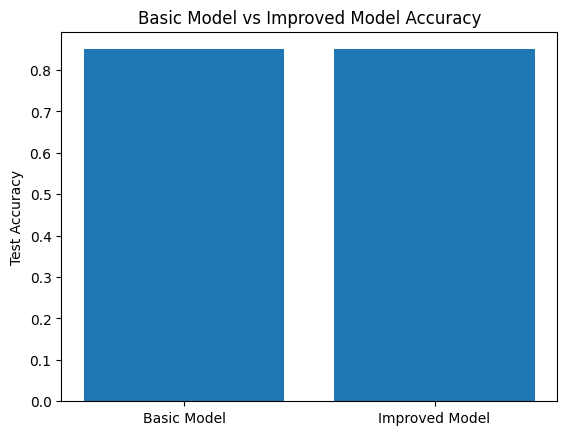

In [26]:
# Plot model accuracy comparison
plt.bar(comparison["Model"], comparison["Test Accuracy"])

# Add title
plt.title("Basic Model vs Improved Model Accuracy")

# Add y-axis label
plt.ylabel("Test Accuracy")

# Show chart
plt.show()

Step 23: Visualize Training Loss

This shows how well the improved model learned during training.

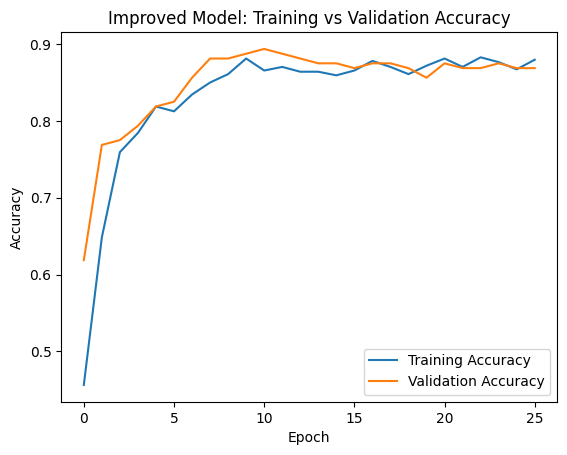

In [27]:
# Plot improved model training accuracy
plt.plot(improved_history.history["accuracy"], label="Training Accuracy")

# Plot improved model validation accuracy
plt.plot(improved_history.history["val_accuracy"], label="Validation Accuracy")

# Add title
plt.title("Improved Model: Training vs Validation Accuracy")

# Add x-axis label
plt.xlabel("Epoch")

# Add y-axis label
plt.ylabel("Accuracy")

# Add legend
plt.legend()

# Show plot
plt.show()

Step 24: Visualize Training Loss

This helps students see whether regularization reduced overfitting.

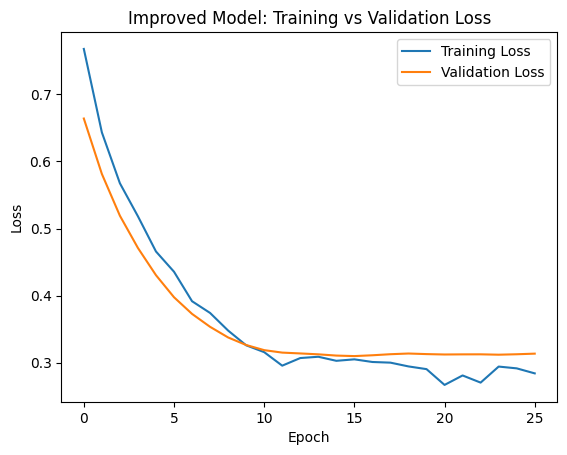

In [28]:
# Plot improved model training loss
plt.plot(improved_history.history["loss"], label="Training Loss")

# Plot improved model validation loss
plt.plot(improved_history.history["val_loss"], label="Validation Loss")

# Add title
plt.title("Improved Model: Training vs Validation Loss")

# Add x-axis label
plt.xlabel("Epoch")

# Add y-axis label
plt.ylabel("Loss")

# Add legend
plt.legend()

# Show plot
plt.show()

Step 25: Make Predictions with Improved Model

The model outputs probabilities. We convert them into pass/fail labels using 0.5 as the threshold.

In [29]:
# Predict probabilities using improved model
y_pred_prob = improved_model.predict(X_test_scaled)

# Convert probabilities into class labels
y_pred = (y_pred_prob > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


Step 26: Convert Probabilities into Class Labels

In [30]:
predicted_classes = (

    y_pred_prob > 0.5

).astype(int)

print(predicted_classes[:10])

[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]]


Step 27: Confusion Matrix

The confusion matrix shows correct and incorrect predictions for both classes.

In [31]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 29  15]
 [ 15 141]]


Step 28: Classification Report

This report shows precision, recall, and F1-score.

In [32]:
from sklearn.metrics import classification_report

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66        44
           1       0.90      0.90      0.90       156

    accuracy                           0.85       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.85      0.85      0.85       200



Step 29: Save the Improved Model Saving the model allows reuse without training again.

In [33]:
# Save improved model
improved_model.save("improved_student_model.keras")

Step 30: Load the Best Saved Model

This confirms that the best model was saved and can be loaded again.

In [34]:
# Load the best model saved by ModelCheckpoint
best_model = keras.models.load_model("best_student_model.keras")

# Show model summary
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,213 (8.65 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,476 (5.77 KB)

# Final Conclusion

This project demonstrated an end-to-end deep learning workflow for predicting student pass/fail outcomes using an Artificial Neural Network.

The dataset contained 1,000 student records with five input features and one binary target variable. The data was divided into training and testing sets using stratified sampling, and the numerical features were standardized before being provided to the neural network.

A baseline neural network with two hidden layers was developed and trained using the Adam optimizer and binary cross-entropy loss. The baseline model achieved **84.5% test accuracy**.

An improved model was then developed using Dropout, learning-rate reduction, Early Stopping, and ModelCheckpoint. The improved model achieved a lower test loss of **0.3159**, compared with **0.3335** for the baseline model. However, its test accuracy was slightly lower at **83.5%**, compared with **84.5%** for the baseline model.

The final classification results showed that the model performed better when predicting students who passed than students who failed. In particular, the recall for the failed class was 0.59, showing that some students who failed were not identified correctly.

Overall, the model demonstrates the practical use of neural networks for student performance prediction. However, it should be used as a supporting early-warning system rather than as the sole basis for educational decisions. Further improvements could include collecting additional predictive features, addressing class imbalance, testing different network architectures, and systematically tuning hyperparameters.